In [21]:
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors

# Resolve the repository root, so the notebook works from any subfolder.
working_dir = Path.cwd().resolve()
repository_root = next(
    parent
    for parent in (working_dir, *working_dir.parents)
    if (parent / "07_postprocess_data" / "local" / "sdm_area_change").is_dir()
)

AREA_CSV = (
    repository_root / "07_postprocess_data" / "local" / "sdm_area_change"
    / "final_amazon_area_ETresid_updated.csv"
)
SPECIES_LIST_FILE = (
    repository_root / "04_rasterize_species" / "local" / "data"
    / "full_species_list_amazon_updated.csv"
)
PLOT_DIR = repository_root / "08_figures" / "appendix" / "area_change" / "plots"
PLOT_DIR.mkdir(parents=True, exist_ok=True)

TIP_ORDER = ["notip", "tip"]
TIME_ORDER = ["2030_2044", "2050_2069", "2080_2099"]
TIME_LABELS = {period: period.replace("_", "-") for period in TIME_ORDER}
ALGORITHM_ORDER = ["GLM", "GAM", "GBM", "RFd"]
RANGE_CLASS_ORDER = ["supersmall", "small", "medium", "large", "superlarge"]
TAXON_ORDER = ["mammals", "birds", "reptiles", "amphibians"]

# Colours used for taxonomic groups in Figure 3.
TAXON_COLORS = {
    "birds": "#0B3D91",
    "mammals": "#6A3D9A",
    "reptiles": "#8B1E1E",
    "amphibians": "#E68613",
}

In [22]:
def require_files(*paths):
    missing = [str(path) for path in paths if not Path(path).is_file()]
    if missing:
        raise FileNotFoundError("Missing required file(s):\n" + "\n".join(missing))


def normalise_species_name(names):
    """Create a matching key independent of dots, hyphens, and underscores."""
    return (
        names.astype("string")
        .str.replace(r"[-.]", "_", regex=True)
        .str.replace(r"_+", "_", regex=True)
    )


def lighten(color, factor=0.55):
    red, green, blue, alpha = mcolors.to_rgba(color)
    return (
        (1 - factor) + factor * red,
        (1 - factor) + factor * green,
        (1 - factor) + factor * blue,
        alpha,
    )


def taxon_palette(taxon):
    """Light no-tipping and full tipping versions of the Figure-3 taxon colour."""
    return {"notip": lighten(TAXON_COLORS[taxon]), "tip": TAXON_COLORS[taxon]}


def select_main_scenarios(dataframe, ssp):
    """Retain no-tipping and tipping-with-deforestation scenarios for one SSP."""
    subset = dataframe.loc[
        (dataframe["ssp"] == ssp)
        & ~(
            (dataframe["tip"] == "tip")
            & (dataframe["deforestation"] == "no_deforestation")
        )
    ].copy()
    subset["time_period"] = pd.Categorical(
        subset["time_period"], categories=TIME_ORDER, ordered=True
    )
    return subset


def finish_figure(fig, filename):
    output_file = PLOT_DIR / filename
    fig.savefig(output_file, dpi=300, bbox_inches="tight")
    print(f"Saved: {output_file}")
    plt.show()

In [23]:
require_files(AREA_CSV, SPECIES_LIST_FILE)
area_data = pd.read_csv(AREA_CSV)
species_metadata = pd.read_csv(SPECIES_LIST_FILE)

# A no-tipping projection has no precipitation-sample dimension. Replicate it
# for the precipitation samples paired with each algorithm/model-run in the
# tipping projections, so both scenarios have a matched MC structure.
tipping_samples = (
    area_data.loc[area_data["tip"] == "tip", ["algo", "model_run", "prec_sample"]]
    .drop_duplicates()
)
notip_expanded = (
    area_data.loc[area_data["tip"] == "notip"]
    .drop(columns="prec_sample", errors="ignore")
    .merge(tipping_samples, on=["algo", "model_run"], how="inner")
)
area_data = pd.concat(
    [notip_expanded, area_data.loc[area_data["tip"] == "tip"]],
    ignore_index=True,
)

# The SDMs contain resident birds only, plus all non-bird taxa. Restrict the
# metadata accordingly before the merge to prevent duplicate seasonal birds.
model_species_metadata = species_metadata.loc[
    (species_metadata["type"] != "birds")
    | (species_metadata["seasonality"] == "resident")
].copy()
model_species_metadata["_species_key"] = normalise_species_name(
    model_species_metadata["Species"]
)
assert not model_species_metadata["_species_key"].duplicated().any(), (
    "Model-species metadata must have one row per normalised species name."
)

area_data["_species_key"] = normalise_species_name(area_data["species_name"])
full_area_data = area_data.merge(
    model_species_metadata[["_species_key", "type", "class"]],
    on="_species_key",
    how="left",
).drop(columns="_species_key")

unmatched = full_area_data["type"].isna().sum()
if unmatched:
    missing_species = sorted(full_area_data.loc[full_area_data["type"].isna(), "species_name"].unique())
    raise ValueError(
        f"{unmatched} area rows could not be matched to model-species metadata: "
        + ", ".join(missing_species)
    )

print(f"Area rows after no-tipping MC expansion: {len(full_area_data):,}")
print(f"Model species represented: {full_area_data['species_name'].nunique():,}")

Area rows after no-tipping MC expansion: 3,456,000
Model species represented: 1,920


      type      class  number_of_species
     birds supersmall                235
     birds      small                211
     birds     medium                214
     birds      large                296
     birds superlarge                189
amphibians supersmall                 46
amphibians      small                 51
amphibians     medium                 45
amphibians      large                 49
amphibians superlarge                 18
   mammals supersmall                 87
   mammals      small                 73
   mammals     medium                 62
   mammals      large                 69
   mammals superlarge                 92
  reptiles supersmall                 32
  reptiles      small                 47
  reptiles     medium                 44
  reptiles      large                 79
  reptiles superlarge                 52


C:\Users\Clemens\AppData\Local\Temp\ipykernel_20232\166688168.py:50: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axis.set_xticklabels(["Birds", "Amphibians", "Mammals", "Reptiles"], fontsize=13, fontweight="bold")


Saved: C:\Users\Clemens\Desktop\amazon_code_public\08_figures\appendix\area_change\plots\number_species_in_class_per_species.png


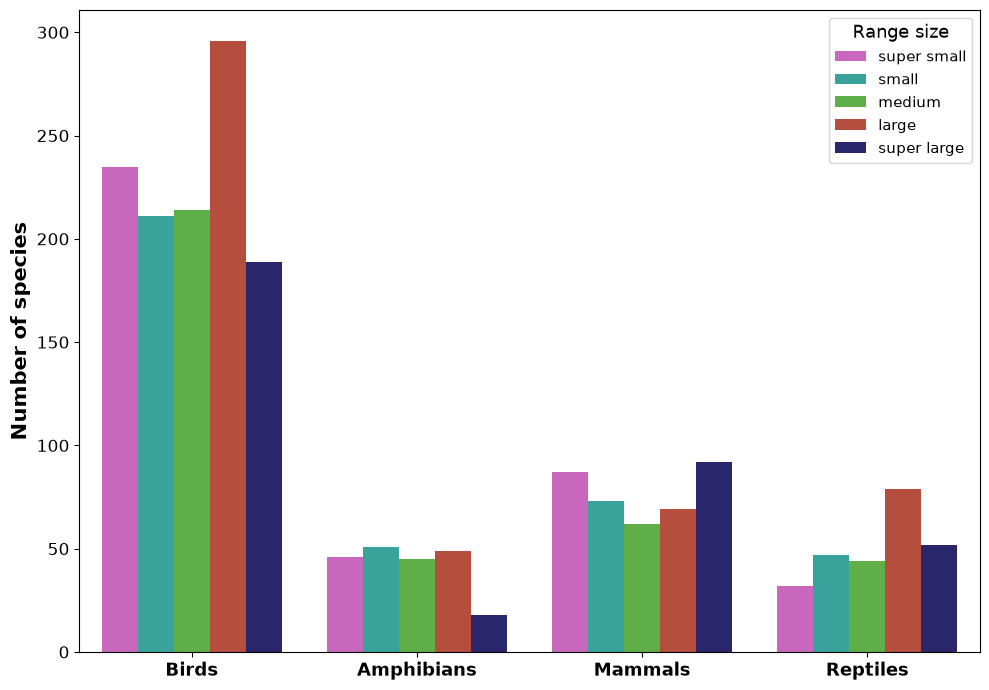

In [25]:
# Number of species in each range-size class across the full species catalogue.
# Unlike the SDM plots, this descriptive overview intentionally includes every
# bird seasonality, reproducing the former summary figure.
catalogue_species_by_class = (
    species_metadata.dropna(subset=["type", "class"])
    .groupby(["type", "class"], observed=True)["Species"]
    .nunique()
    .rename("number_of_species")
    .reset_index()
)
catalogue_species_by_class["type"] = pd.Categorical(
    catalogue_species_by_class["type"],
    categories=["birds", "amphibians", "mammals", "reptiles"],
    ordered=True,
)
catalogue_species_by_class["class"] = pd.Categorical(
    catalogue_species_by_class["class"], categories=RANGE_CLASS_ORDER, ordered=True
)
catalogue_species_by_class = catalogue_species_by_class.sort_values(["type", "class"])
print(catalogue_species_by_class.to_string(index=False))

range_class_colours = {
    "supersmall": "#D857CA",
    "small": "#27B3AA",
    "medium": "#57BF36",
    "large": "#C94028",
    "superlarge": "#201A78",
}
range_class_labels = {
    "supersmall": "super small",
    "small": "small",
    "medium": "medium",
    "large": "large",
    "superlarge": "super large",
}

fig, axis = plt.subplots(figsize=(10, 7))
sns.barplot(
    data=catalogue_species_by_class,
    x="type",
    y="number_of_species",
    hue="class",
    order=["birds", "amphibians", "mammals", "reptiles"],
    hue_order=RANGE_CLASS_ORDER,
    palette=range_class_colours,
    ax=axis,
)
axis.set_xlabel("")
axis.set_ylabel("Number of species", fontsize=15, fontweight="bold")
axis.set_xticklabels(["Birds", "Amphibians", "Mammals", "Reptiles"], fontsize=13, fontweight="bold")
axis.tick_params(axis="y", labelsize=12)
handles, _ = axis.get_legend_handles_labels()
axis.legend(
    handles,
    [range_class_labels[range_class] for range_class in RANGE_CLASS_ORDER],
    title="Range size",
    title_fontsize=13,
    fontsize=11,
    loc="upper right",
)
fig.tight_layout()
finish_figure(fig, "number_species_in_class_per_species.png")

In [4]:
# Change these two settings to produce the main taxon/class/algorithm plots.
ssp = "ssp245"
dispersal_scenario = "full_dispersal"
change_column = f"relative_change_amazon_area_{dispersal_scenario}"

In [5]:
median_by_taxon = (
    full_area_data.groupby(
        ["ssp", "tip", "deforestation", "time_period", "algo", "model_run", "prec_sample", "type"],
        dropna=False,
    )[change_column]
    .median()
    .reset_index()
)
taxon_plot_data = select_main_scenarios(median_by_taxon, ssp)

C:\Users\Clemens\AppData\Local\Temp\ipykernel_20232\3640779678.py:24: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axis.set_yticklabels([TIME_LABELS[period] for period in TIME_ORDER], rotation=90, va="center", fontsize=16, fontweight="bold")
C:\Users\Clemens\AppData\Local\Temp\ipykernel_20232\3640779678.py:24: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axis.set_yticklabels([TIME_LABELS[period] for period in TIME_ORDER], rotation=90, va="center", fontsize=16, fontweight="bold")


Saved: C:\Users\Clemens\Desktop\amazon_code_public\08_figures\appendix\area_change\plots\relative_area_loss_amazon_per_species_ssp245_full_dispersal.png


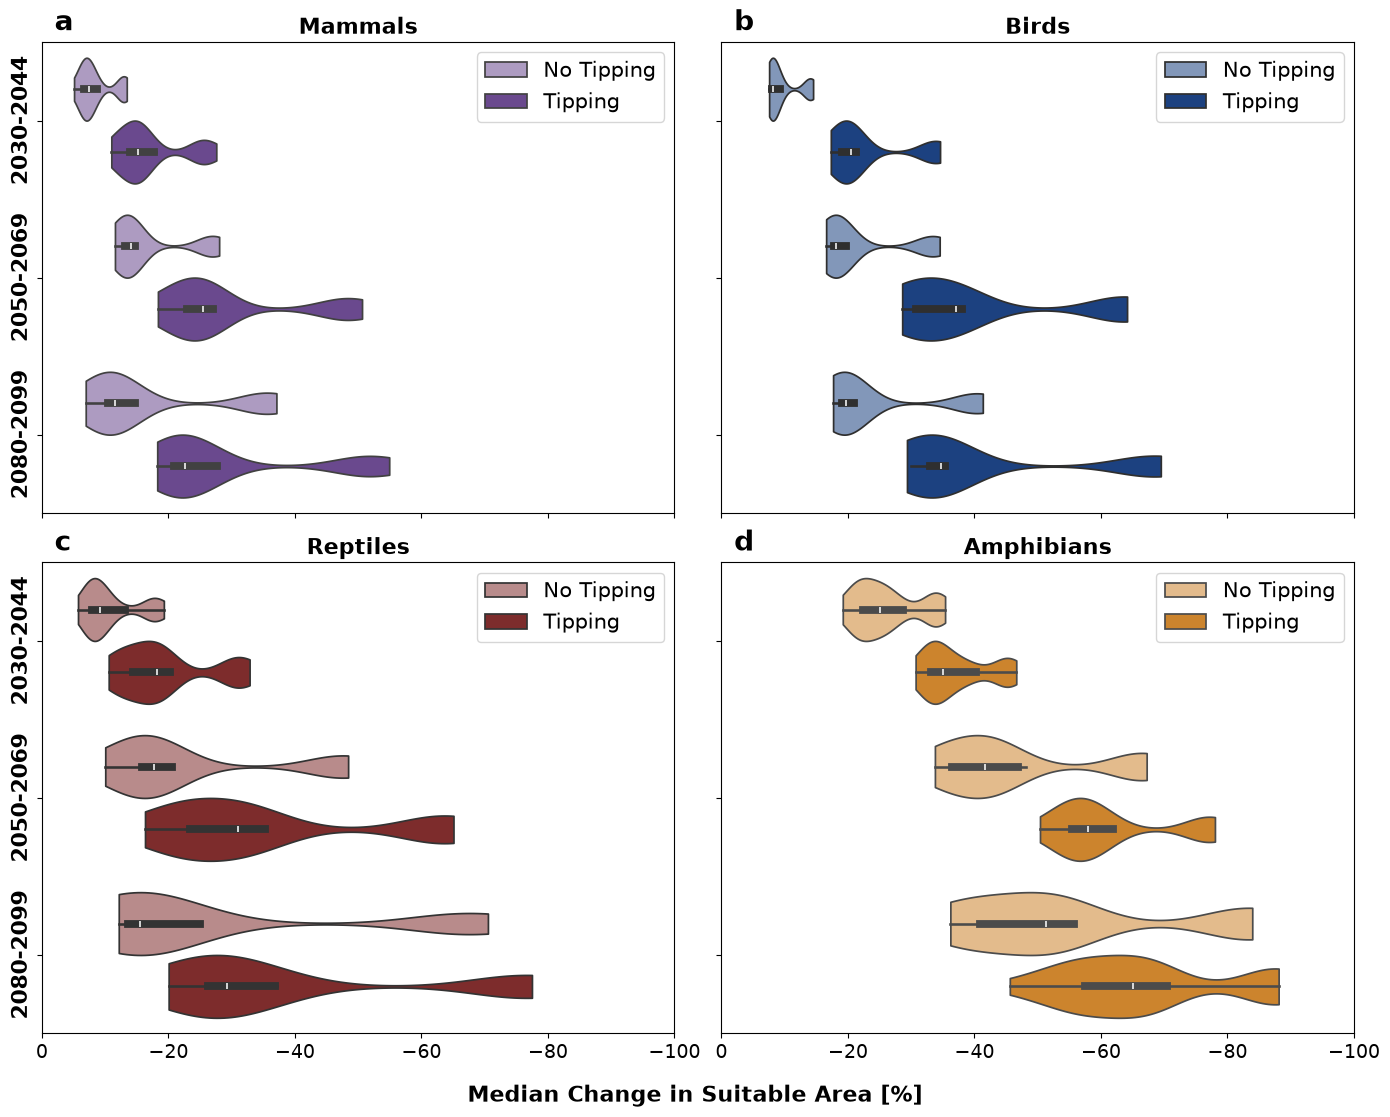

In [20]:
fig, axes = plt.subplots(2, 2, figsize=(14, 12), sharex=True, sharey=True)
axes = axes.flatten()

for index, (axis, taxon) in enumerate(zip(axes, TAXON_ORDER)):
    taxon_data = taxon_plot_data.loc[taxon_plot_data["type"] == taxon]
    sns.violinplot(
        data=taxon_data,
        x=change_column,
        y="time_period",
        hue="tip",
        hue_order=TIP_ORDER,
        palette=taxon_palette(taxon),
        cut=0,
        density_norm="width",
        ax=axis,
    )
    axis.set_title(taxon.capitalize(), fontsize=16, fontweight="bold")
    axis.set_xlim(0, -100)
    axis.set_xlabel("")
    axis.set_ylabel("")
    axis.tick_params(axis="x", labelsize=14)

    if index in [0, 2]:
        axis.set_yticklabels([TIME_LABELS[period] for period in TIME_ORDER], rotation=90, va="center", fontsize=16, fontweight="bold")
    else:
        axis.tick_params(axis="y", labelleft=False)

    handles, _ = axis.get_legend_handles_labels()
    axis.legend(handles, ["No Tipping", "Tipping"], fontsize=15)
    axis.text(0.02, 1.07, chr(ord("a") + index), transform=axis.transAxes, fontsize=20, fontweight="bold", va="top")

fig.text(0.5, 0.08, "Median Change in Suitable Area [%]", ha="center", fontsize=16, fontweight="bold")
fig.tight_layout(rect=[0, 0.10, 1, 1])
finish_figure(fig, f"relative_area_loss_amazon_per_species_{ssp}_{dispersal_scenario}.png")

In [7]:
median_by_algorithm = (
    full_area_data.groupby(
        ["ssp", "tip", "deforestation", "time_period", "algo", "model_run", "prec_sample"],
        dropna=False,
    )[change_column]
    .median()
    .reset_index()
)
algorithm_plot_data = select_main_scenarios(median_by_algorithm, ssp)

C:\Users\Clemens\AppData\Local\Temp\ipykernel_20232\1584580744.py:31: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(data=algorithm_plot_data, x=change_column, y="y_cat", order=y_order, cut=0, linewidth=1, scale="width", bw=0.3, color="#4C72B0", ax=axis)
C:\Users\Clemens\AppData\Local\Temp\ipykernel_20232\1584580744.py:31: FutureWarning: 

The `bw` parameter is deprecated in favor of `bw_method`/`bw_adjust`.
Setting `bw_method=0.3`, but please see docs for the new parameters
and update your code. This will become an error in seaborn v0.15.0.

  sns.violinplot(data=algorithm_plot_data, x=change_column, y="y_cat", order=y_order, cut=0, linewidth=1, scale="width", bw=0.3, color="#4C72B0", ax=axis)
C:\Users\Clemens\AppData\Local\Temp\ipykernel_20232\1584580744.py:38: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a Fixed

Saved: C:\Users\Clemens\Desktop\amazon_code_public\08_figures\appendix\area_change\plots\relative_area_loss_amazon_per_algo_ssp245_full_dispersal.png


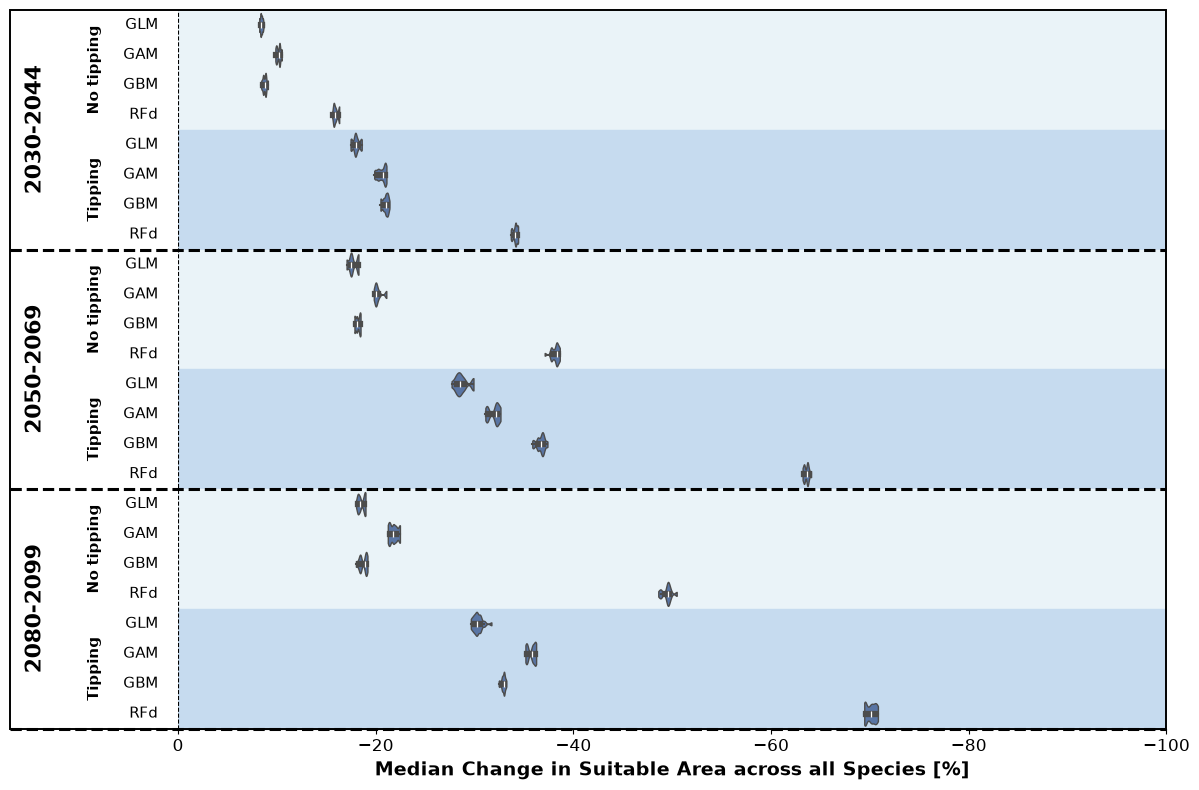

In [8]:
# Detailed algorithm plot, with period and scenario blocks shown at left.
light_blue, dark_blue = "#EAF3F8", "#C6DBEF"
y_order, block_info = [], []
y = 0
for period in TIME_ORDER:
    for scenario in TIP_ORDER:
        y_start = y
        for algorithm in ALGORITHM_ORDER:
            y_order.append(f"{period} | {scenario} | {algorithm}")
            y += 1
        block_info.append((y_start, y - 1, period, scenario))

algorithm_plot_data["y_cat"] = algorithm_plot_data.apply(
    lambda row: f"{row['time_period']} | {row['tip']} | {row['algo']}", axis=1
)
fig, axis = plt.subplots(figsize=(12, 8))

for y_start, y_end, period, scenario in block_info:
    facecolor = light_blue if scenario == "notip" else dark_blue
    axis.axhspan(y_start - 0.5, y_end + 0.5, color=facecolor, zorder=0)
    axis.add_patch(plt.Rectangle((-0.11, y_start - 0.5), 0.05, y_end - y_start + 1, transform=axis.get_yaxis_transform(), facecolor=facecolor, edgecolor="black", linewidth=0.6, zorder=1))
    axis.text(-0.085, (y_start + y_end) / 2, "No tipping" if scenario == "notip" else "Tipping", rotation=90, ha="center", va="center", fontsize=11, fontweight="bold", transform=axis.get_yaxis_transform(), zorder=2)

for period in TIME_ORDER:
    period_blocks = [block for block in block_info if block[2] == period]
    y_start, y_end = period_blocks[0][0], period_blocks[-1][1]
    axis.hlines(y_end + 0.5, -0.17, 1, transform=axis.get_yaxis_transform(), color="black", linestyle="--", linewidth=2.2, zorder=5, clip_on=False)
    axis.add_patch(plt.Rectangle((-0.17, y_start - 0.5), 0.05, y_end - y_start + 1, transform=axis.get_yaxis_transform(), facecolor="white", edgecolor="black", linewidth=0.8, zorder=1))
    axis.text(-0.145, (y_start + y_end) / 2, TIME_LABELS[period], rotation=90, ha="center", va="center", fontsize=16, fontweight="bold", transform=axis.get_yaxis_transform(), zorder=2)

sns.violinplot(data=algorithm_plot_data, x=change_column, y="y_cat", order=y_order, cut=0, linewidth=1, scale="width", bw=0.3, color="#4C72B0", ax=axis)
axis.set_xlim(0, -100)
axis.axvline(0, color="black", linestyle="--", linewidth=0.8)
axis.set_xlabel("Median Change in Suitable Area across all Species [%]", fontsize=14, fontweight="bold")
axis.set_ylabel("")
axis.tick_params(axis="x", labelsize=12)
axis.tick_params(axis="y", length=0)
axis.set_yticklabels([""] * len(y_order))
sns.despine(ax=axis, left=True)

for y, label in enumerate(y_order):
    axis.text(-0.02, y, label.split(" | ")[-1], transform=axis.get_yaxis_transform(), ha="right", va="center", fontsize=11)

axis.add_patch(plt.Rectangle((-0.17, -0.5), 1.17, len(y_order), transform=axis.get_yaxis_transform(), fill=False, edgecolor="black", linewidth=1.4, zorder=20, clip_on=False))
fig.tight_layout()
finish_figure(fig, f"relative_area_loss_amazon_per_algo_{ssp}_{dispersal_scenario}.png")

In [9]:
median_by_class = (
    full_area_data.groupby(
        ["ssp", "tip", "deforestation", "time_period", "algo", "model_run", "prec_sample", "class"],
        dropna=False,
    )[change_column]
    .median()
    .reset_index()
)
class_plot_data = select_main_scenarios(median_by_class, ssp)

CLASS_COLORS = {
    "supersmall": ["#F390E6", "#FA45E2F4"],
    "small": ["#ABEEF7", "#03CEC4F4"],
    "medium": ["#A3FC87", "#4DDB22F4"],
    "large": ["#E28383", "#DB2E0FF4"],
    "superlarge": ["#6876A5", "#080683F4"],
}

C:\Users\Clemens\AppData\Local\Temp\ipykernel_20232\4178322041.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axis.set_yticklabels([TIME_LABELS[period] for period in TIME_ORDER], rotation=90, va="center", fontsize=14, fontweight="bold")
C:\Users\Clemens\AppData\Local\Temp\ipykernel_20232\4178322041.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axis.set_yticklabels([TIME_LABELS[period] for period in TIME_ORDER], rotation=90, va="center", fontsize=14, fontweight="bold")
C:\Users\Clemens\AppData\Local\Temp\ipykernel_20232\4178322041.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axis.set_yticklabels([TIME_LABELS[peri

Saved: C:\Users\Clemens\Desktop\amazon_code_public\08_figures\appendix\area_change\plots\relative_area_loss_amazon_per_range_size_class_ssp245_full_dispersal.png


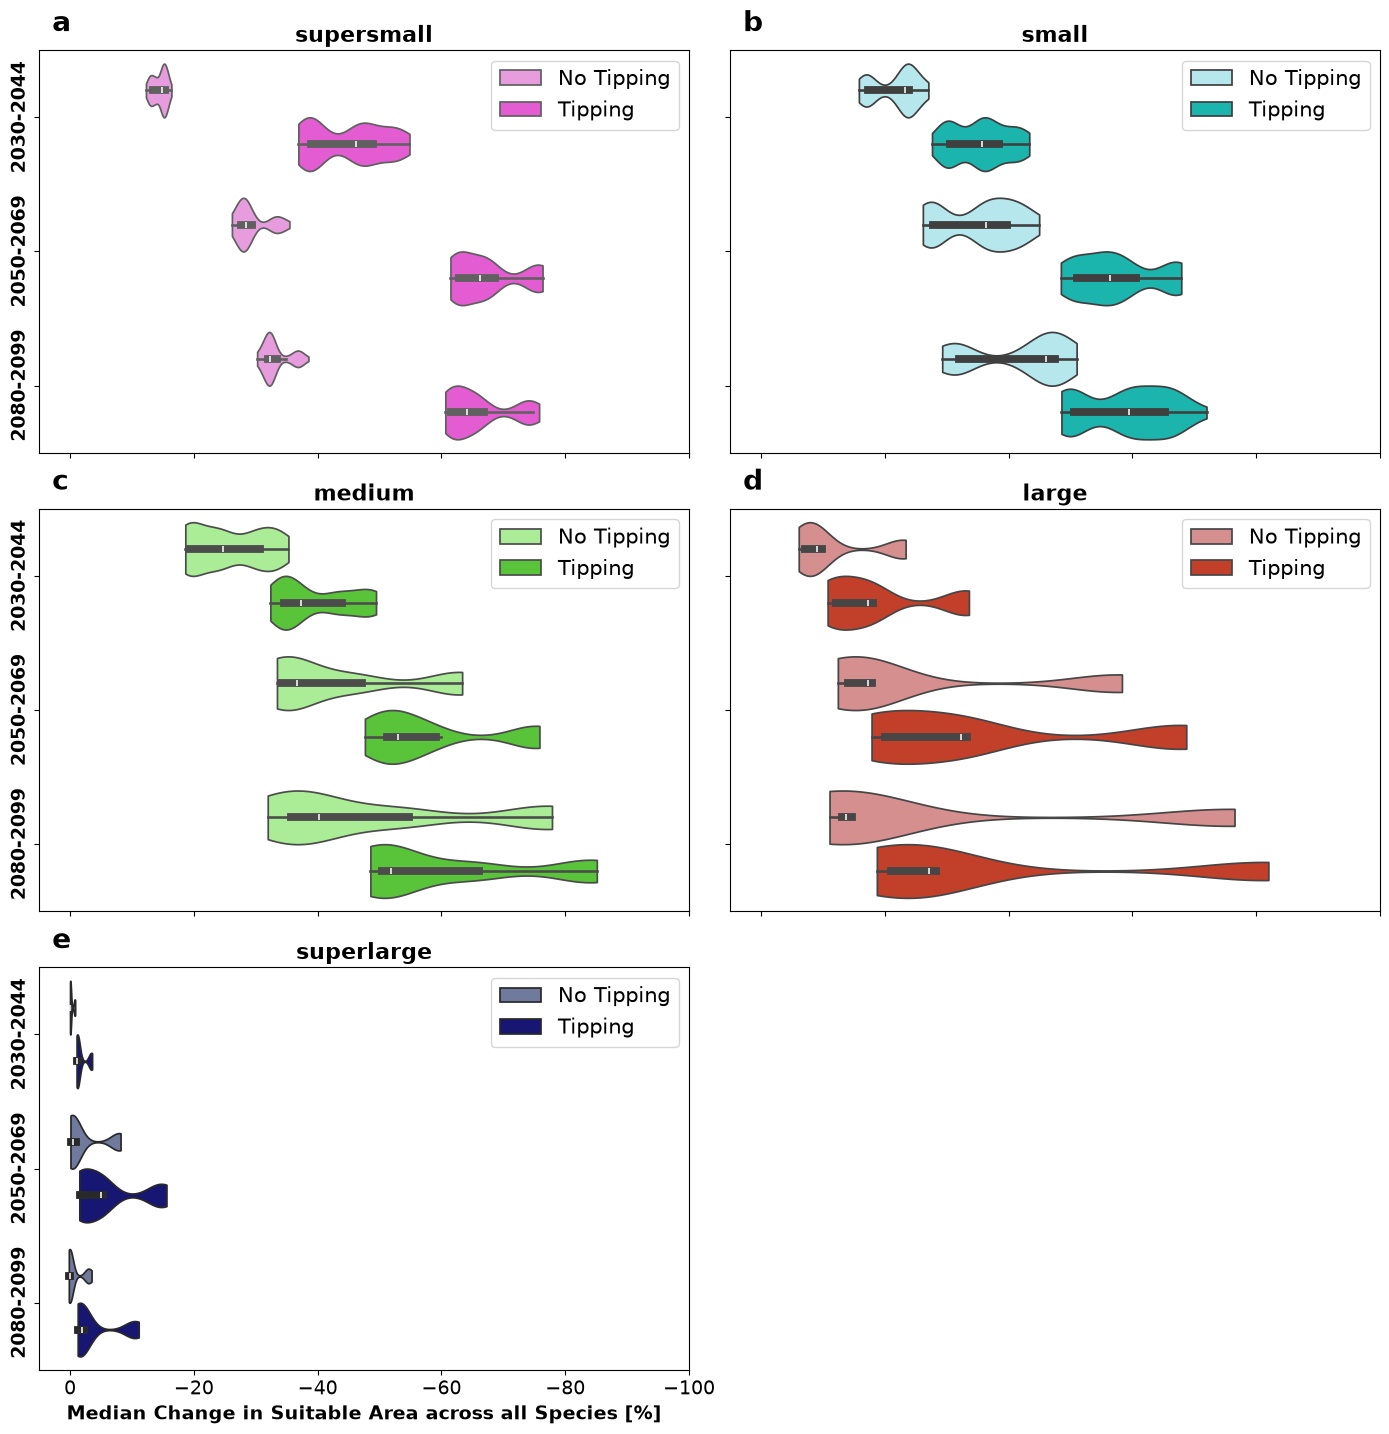

In [19]:
fig, axes = plt.subplots(3, 2, figsize=(14, 16), sharex=True, sharey=True)
axes = axes.flatten()

for index, range_class in enumerate(RANGE_CLASS_ORDER):
    axis = axes[index]
    class_data = class_plot_data.loc[class_plot_data["class"] == range_class]
    sns.violinplot(data=class_data, x=change_column, y="time_period", hue="tip", hue_order=TIP_ORDER, palette={"notip": CLASS_COLORS[range_class][0], "tip": CLASS_COLORS[range_class][1]}, cut=0, density_norm="width", ax=axis)
    axis.set_title(range_class, fontsize=16, fontweight="bold")
    axis.set_xlim(5, -100)
    axis.set_xlabel("")
    axis.set_ylabel("")
    if index % 2 == 0:
        axis.set_yticklabels([TIME_LABELS[period] for period in TIME_ORDER], rotation=90, va="center", fontsize=14, fontweight="bold")
    else:
        axis.tick_params(axis="y", labelleft=False)
    axis.tick_params(axis="x", labelsize=14)
    handles, _ = axis.get_legend_handles_labels()
    axis.legend(handles, ["No Tipping", "Tipping"], fontsize=15)
    axis.text(0.02, 1.1, chr(ord("a") + index), transform=axis.transAxes, fontsize=20, fontweight="bold", va="top")

axes[3].set_xlabel("Median Change in Suitable Area across all Species [%]", fontsize=14, fontweight="bold")
axes[4].set_xlabel("Median Change in Suitable Area across all Species [%]", fontsize=14, fontweight="bold")
axes[5].remove()
fig.tight_layout(rect=[0, 0.10, 1, 1])
finish_figure(fig, f"relative_area_loss_amazon_per_range_size_class_{ssp}_{dispersal_scenario}.png")

In [12]:
def median_all_species_for_dispersal(dispersal):
    column = f"relative_change_amazon_area_{dispersal}"
    summary = (
        full_area_data.groupby(
            ["ssp", "tip", "deforestation", "time_period", "algo", "model_run", "prec_sample"],
            dropna=False,
        )[column]
        .median()
        .reset_index()
    )
    return select_main_scenarios(summary, "ssp245"), select_main_scenarios(summary, "ssp370"), column

full_245, full_370, full_column = median_all_species_for_dispersal("full_dispersal")
none_245, none_370, none_column = median_all_species_for_dispersal("no_dispersal")

C:\Users\Clemens\AppData\Local\Temp\ipykernel_20232\2821096482.py:25: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axis.set_yticklabels([TIME_LABELS[period] for period in TIME_ORDER], rotation=90, va="center", fontsize=13, fontweight="bold")
C:\Users\Clemens\AppData\Local\Temp\ipykernel_20232\2821096482.py:25: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axis.set_yticklabels([TIME_LABELS[period] for period in TIME_ORDER], rotation=90, va="center", fontsize=13, fontweight="bold")
C:\Users\Clemens\AppData\Local\Temp\ipykernel_20232\2821096482.py:25: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axis.set_yticklabels([TIME_LABELS[peri

Saved: C:\Users\Clemens\Desktop\amazon_code_public\08_figures\appendix\area_change\plots\area_loss_comparison_ssps_dispersal_scenarios.png


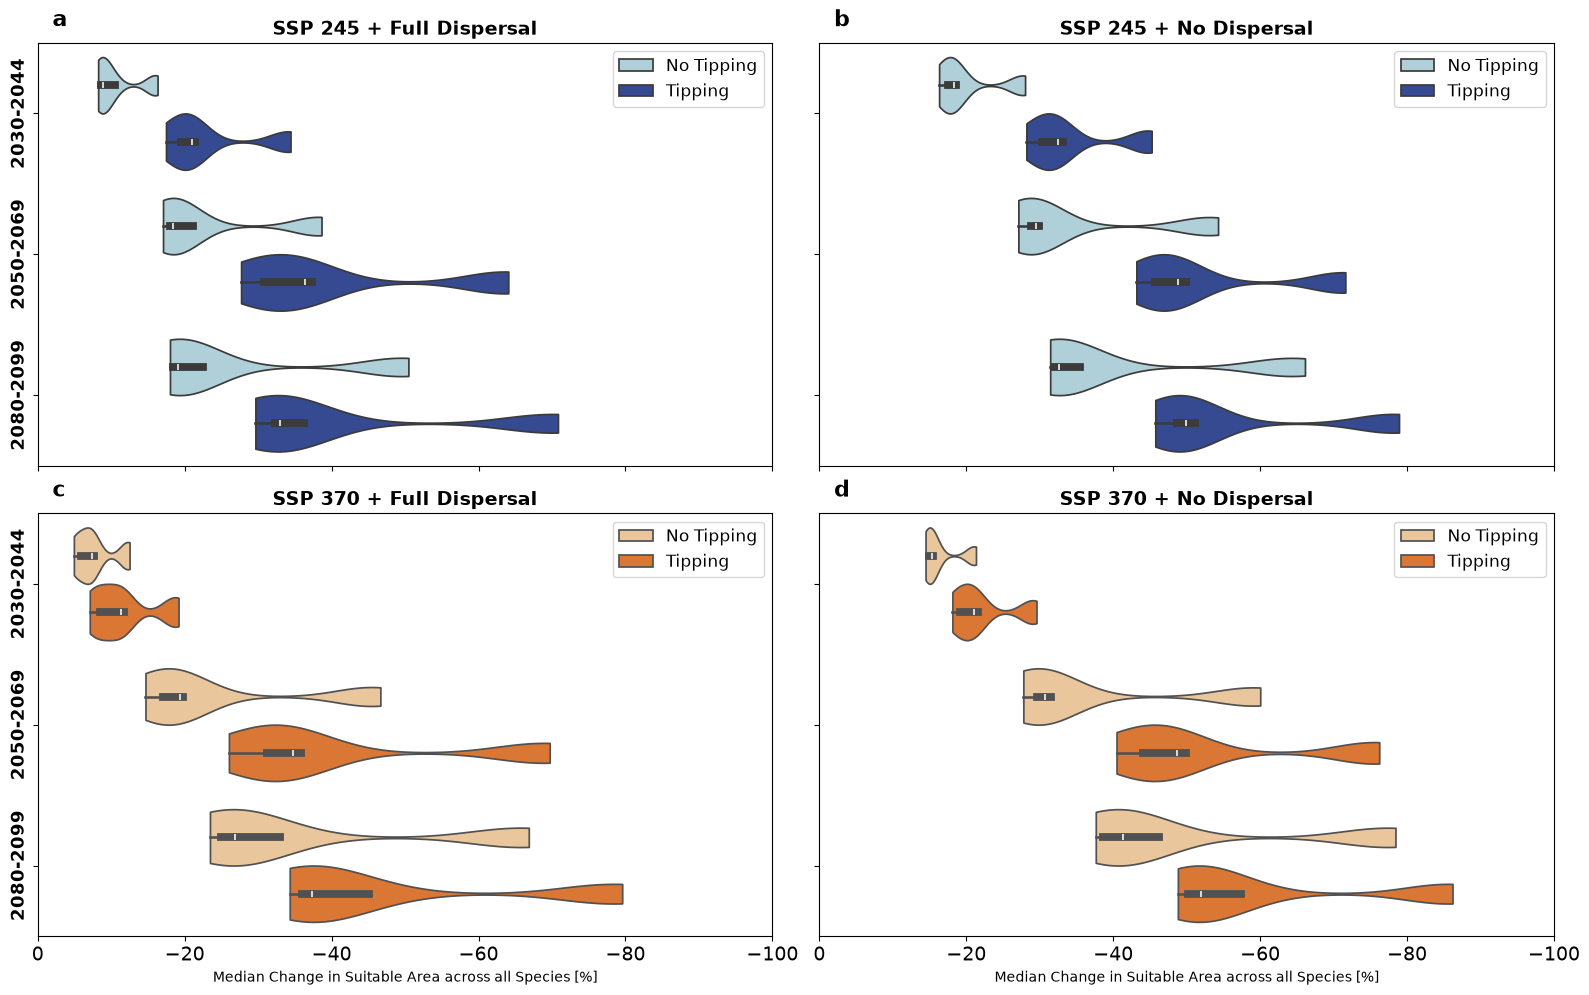

In [18]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10), sharex=True, sharey=True)
panel_specs = [
    (axes[0, 0], full_245, full_column, ["#A8D4DF", "#2642A0F4"], "SSP 245 + Full Dispersal"),
    (axes[0, 1], none_245, none_column, ["#A8D4DF", "#2642A0F4"], "SSP 245 + No Dispersal"),
    (axes[1, 0], full_370, full_column, ["#F7C790", "#F5721AF4"], "SSP 370 + Full Dispersal"),
    (axes[1, 1], none_370, none_column, ["#F7C790", "#F5721AF4"], "SSP 370 + No Dispersal"),
]

for index, (axis, data, column, palette, title) in enumerate(panel_specs):
    sns.violinplot(
    data=data,
    x=column,
    y="time_period",
    hue="tip",
    hue_order=TIP_ORDER,
    palette=palette,
    cut=0,
    density_norm="width",
    ax=axis,
)
    axis.set_title(title, fontsize=14, fontweight="bold")
    axis.set_xlim(0, -100)
    axis.set_xlabel("" if index < 2 else "Median Change in Suitable Area across all Species [%]")
    axis.set_ylabel("")
    axis.set_yticklabels([TIME_LABELS[period] for period in TIME_ORDER], rotation=90, va="center", fontsize=13, fontweight="bold")
    axis.tick_params(axis="x", labelsize=14)
    handles, _ = axis.get_legend_handles_labels()
    axis.legend(handles, ["No Tipping", "Tipping"], fontsize=12)
    axis.text(0.02, 1.08, chr(ord("a") + index), transform=axis.transAxes, fontsize=16, fontweight="bold", va="top")

fig.tight_layout()
finish_figure(fig, "area_loss_comparison_ssps_dispersal_scenarios.png")

In [28]:
# Number of modelled species by taxon.
# This includes all mammals, reptiles, amphibians, and resident birds only.

modelled_species = model_species_metadata.copy()

species_type_counts = (
    modelled_species.groupby("type", observed=True)["Species"]
    .nunique()
    .reindex(["amphibians", "reptiles", "mammals", "birds"])
    .rename("number_of_species")
    .reset_index()
)

total_modelled_species = species_type_counts["number_of_species"].sum()

print(species_type_counts.to_string(index=False))
print(f"\nTotal number of modelled species: {total_modelled_species}")

      type  number_of_species
amphibians                209
  reptiles                254
   mammals                383
     birds               1074

Total number of modelled species: 1920


In [29]:
# Number of modelled species per range-size class and taxon.
# Breeding and non-breeding birds remain excluded.

species_per_range_class = (
    modelled_species.groupby(["class", "type"], observed=True)["Species"]
    .nunique()
    .unstack(fill_value=0)
    .reindex(
        index=RANGE_CLASS_ORDER,
        columns=["amphibians", "reptiles", "mammals", "birds"],
        fill_value=0,
    )
    .rename(columns={"birds": "resident_birds"})
)

species_per_range_class["all_modelled_species"] = species_per_range_class.sum(axis=1)

print(species_per_range_class)
print("\nTotal across range-size classes:")
print(species_per_range_class.sum(axis=0))

type        amphibians  reptiles  mammals  resident_birds  \
class                                                       
supersmall          46        32       87             233   
small               51        47       73             202   
medium              45        44       62             193   
large               49        79       69             276   
superlarge          18        52       92             170   

type        all_modelled_species  
class                             
supersmall                   398  
small                        373  
medium                       344  
large                        473  
superlarge                   332  

Total across range-size classes:
type
amphibians               209
reptiles                 254
mammals                  383
resident_birds          1074
all_modelled_species    1920
dtype: int64
